# JEV game-theory benchmark: symmetric 2x2 games

Benchmark 1 of a performance suite for `typesafe/jev-1.13`. Each trial hands JEV a
payoff table as a JSON `state`, tells it to maximise its own total payoff, and reads
back how much probability it puts on the cooperative action. Seven blocks each move
one factor away from a common baseline (prisoner's dilemma, actions labelled A and B,
one-shot, unknown opponent):

| Block | What varies | What theory says |
|---|---|---|
| `family` | five ordinal 2x2 families | cooperate in Harmony, defect in the prisoner's dilemma and Deadlock |
| `greed_fear` | Rapoport's greed and fear indices | defect everywhere |
| `delta_sweep` | continuation probability, three payoff sets | cooperate against tit-for-tat only above the grim-trigger threshold |
| `horizon` | one-shot, known-finite, open-ended | backward induction vs unknown; cooperate-then-defect vs committed tit-for-tat |
| `opponent` | six announced opponent strategies | best response to each |
| `framing` | six wordings of the two actions | no change |
| `affine` | six positive affine rescalings of the payoffs | no change |

Every cell runs under both presentations (which letter is cooperative, or which option
is listed first), so presentation bias cancels in the aggregates and is reported on its
own. Nothing in a request names the game, the manipulation or the correct answer.

The game logic lives in `jev_bench/games.py`, the trial design in `jev_bench/design.py`,
and the scoring functions in `jev_bench/metrics.py`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from jev_bench import metrics as M
from jev_bench.design import build_trials
import run_game_theory_benchmark as runner

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## What one request looks like

The baseline prisoner's dilemma, cooperative action presented as "A". The analysis
metadata attached to each trial (block, family, correct answer) is never sent.

In [2]:
trials = build_trials()
example = next(t for t in trials if t['block'] == 'family'
               and t['family'] == 'prisoners_dilemma' and t['coop_first']
               and t['instruction'] == 'self_interest' and t['repetition'] == 0)
print(json.dumps(example['payload'], indent=2))

{
  "state": {
    "setting": "You and one other player each pick an action at the same time, without communicating.",
    "structure": "You play this once and only once. You will never interact with the other player again, and nobody else will learn what you chose.",
    "your_payoff": {
      "you play A and they play A": 3,
      "you play A and they play B": 0,
      "you play B and they play A": 5,
      "you play B and they play B": 1
    },
    "their_payoff": {
      "they play A and you play A": 3,
      "they play A and you play B": 0,
      "they play B and you play A": 5,
      "they play B and you play B": 1
    },
    "payoff_note": "Payoffs are in points. A higher number is always better for the player receiving it."
  },
  "questions": {
    "action": {
      "type": "choice",
      "instructions": "You are the player described in the state. Choose the action that maximises your own total payoff. Ignore every other consideration.",
      "criteria": {
        "A": "you 

In [3]:
design = (pd.DataFrame(trials).groupby('block')
          .agg(trials=('trial_id', 'size'), distinct_requests=('record_key', 'nunique'),
               scoreable=('best_response', lambda s: int(s.notna().sum())))
          .reset_index())
display(design)
print(f"{len(trials):,} trials over {len({t['record_key'] for t in trials}):,} distinct requests")

,block,trials,distinct_requests,scoreable
0,affine,192,192,192
1,delta_sweep,792,792,384
2,family,160,160,96
3,framing,192,192,192
4,greed_fear,432,432,432
5,horizon,224,224,176
6,opponent,192,192,176


2,184 trials over 2,024 distinct requests


## Collection

Answers are cached on disk by the exact bytes of each request, so re-running this cell
costs nothing once the benchmark has been collected.

In [4]:
RUN_DIR = runner.main()
OUT = RUN_DIR / 'metrics'
OUT.mkdir(exist_ok=True)

d = pd.read_csv(RUN_DIR / 'trials.csv')
d = d[d.status == 'ok'].copy()
print(f'{len(d):,} scored trials')

def save(name, table):
    table.to_csv(OUT / f'{name}.csv', index=False)
    return table

run directory: jev_bench_runs/game-theory-2898947bb72f3502
2,184 trials covering 2,024 distinct requests; 0 to fetch



2,184 of 2,184 trials collected (100.00%)
distinct requests 2,024  total cost $0.0598  median latency 0.26s

wrote jev_bench_runs/game-theory-2898947bb72f3502/trials.csv
2,184 scored trials


## 1. Does the answer track the ordinal structure of the game?

Theory's ranking, most to least cooperative: Harmony (cooperating dominates), stag hunt
(cooperating is payoff-dominant but risky), chicken (anti-coordination), prisoner's
dilemma (defecting dominates), Deadlock (defecting dominates and mutual defection is
also the efficient outcome).

,family,n,p_coop,dominant,ci_low,ci_high,theory_rank,observed_rank
2,harmony,32,0.887813,cooperate,0.875938,0.899062,0,0
4,stag_hunt,32,0.724375,None,0.715313,0.733758,1,1
0,chicken,32,0.424063,None,0.405625,0.441562,2,2
3,prisoners_dilemma,32,0.274062,defect,0.260000,0.289062,3,3
1,deadlock,32,0.087188,defect,0.076875,0.097812,4,4


Spearman rho between observed and theoretical ranking: 1.000


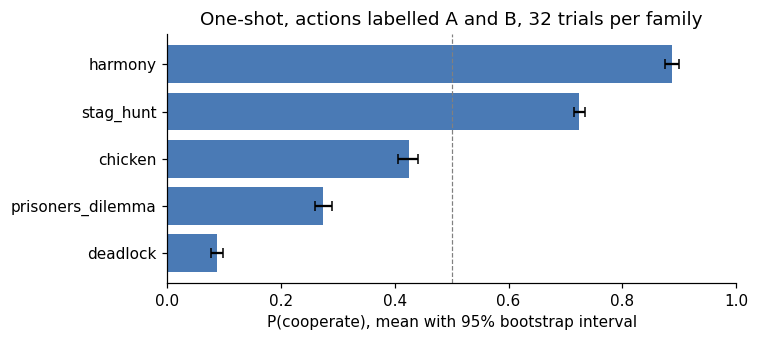

In [5]:
family = d[d.block == 'family']
order = (family.groupby('family')
         .agg(n=('p_coop_choice', 'size'), p_coop=('p_coop_choice', 'mean'),
              dominant=('dominant', 'first'))
         .reset_index().sort_values('p_coop', ascending=False))
ci = [M.bootstrap_ci(family[family.family == f].p_coop_choice.to_numpy()) for f in order.family]
order['ci_low'], order['ci_high'] = [c[1] for c in ci], [c[2] for c in ci]
THEORY_RANK = {'harmony': 0, 'stag_hunt': 1, 'chicken': 2, 'prisoners_dilemma': 3, 'deadlock': 4}
order['theory_rank'] = order.family.map(THEORY_RANK)
order['observed_rank'] = range(len(order))
rho = order.theory_rank.corr(order.observed_rank, method='spearman')
display(save('family_ordering', order))
print(f'Spearman rho between observed and theoretical ranking: {rho:.3f}')

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(order.family, order.p_coop, color='#4a7ab5',
        xerr=[order.p_coop - order.ci_low, order.ci_high - order.p_coop], capsize=3)
ax.axvline(0.5, color='grey', lw=0.8, ls='--')
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('P(cooperate), mean with 95% bootstrap interval')
ax.set_title('One-shot, actions labelled A and B, 32 trials per family')
plt.tight_layout()
plt.show()

In [6]:
instruction = family.groupby(['family', 'instruction'])['p_coop_choice'].mean().unstack().reset_index()
# Positive means "maximise your own payoff" moved the answer towards the payoff-maximising action.
instruction['shift_towards_payoff'] = np.where(
    instruction.family == 'harmony',
    instruction['self_interest'] - instruction['neutral'],
    instruction['neutral'] - instruction['self_interest'])
display(save('instruction_effect', instruction))

instruction,family,neutral,self_interest,shift_towards_payoff
0,chicken,0.441875,0.406250,0.035625
1,deadlock,0.116250,0.058125,0.058125
2,harmony,0.863750,0.911875,0.048125
3,prisoners_dilemma,0.309375,0.238750,0.070625
4,stag_hunt,0.718750,0.730000,-0.011250


## 2. Accuracy wherever theory gives one unambiguous answer

`accuracy` is the share of trials whose picked action is the best response;
`p_best_action` is the mean probability mass on it. Stag hunt, chicken, and any
open-ended game against an unspecified opponent are never scored.

In [7]:
display(save('accuracy_by_block', M.accuracy_table(d, ['block'])))
display(save('accuracy_by_family', M.accuracy_table(family, ['family'])))

scoreable = d[d.best_response.notna()]
correct = scoreable.picked_cooperate == (scoreable.best_response == 'cooperate')
point, lo, hi = M.bootstrap_ci(correct.to_numpy().astype(float))
print(f'overall accuracy on {len(scoreable):,} scoreable trials: {point:.3f} [{lo:.3f}, {hi:.3f}]')

,block,n,best_response,accuracy,p_best_action,ci_low,ci_high
0,affine,192,mixed,0.958333,0.830885,0.809219,0.851720
1,delta_sweep,384,mixed,0.664062,0.520885,0.515391,0.526589
2,family,96,mixed,1.000000,0.842187,0.823646,0.859898
3,framing,192,mixed,0.671875,0.682552,0.641458,0.722396
4,greed_fear,432,defect,1.000000,0.762245,0.757893,0.766597
5,horizon,176,mixed,0.352273,0.489034,0.468295,0.510398
6,opponent,176,mixed,0.750000,0.685852,0.651705,0.719661


,family,n,best_response,accuracy,p_best_action,ci_low,ci_high
0,deadlock,32,defect,1.0,0.912813,0.902187,0.923125
1,harmony,32,cooperate,1.0,0.887813,0.875938,0.899062
2,prisoners_dilemma,32,defect,1.0,0.725938,0.710938,0.740000


overall accuracy on 1,648 scoreable trials: 0.783 [0.763, 0.803]


## 3. Within one family, does it track how much there is to gain and to lose?

Rapoport's indices: greed = (T − R)/(R − P), fear = (P − S)/(R − P). Every cell is a
prisoner's dilemma, so the normative surface is zero everywhere.

P(cooperate) ~ -0.0166 log greed -0.0062 log fear + 0.2264


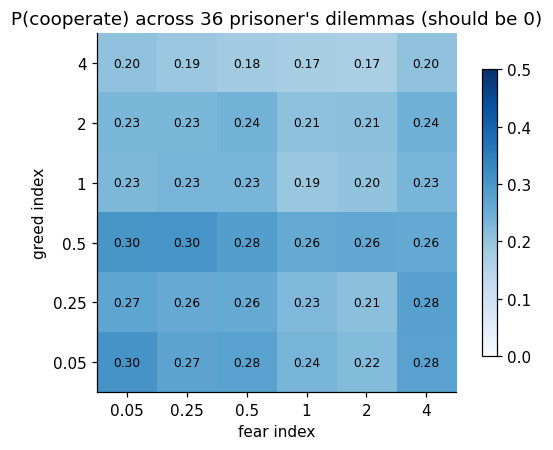

In [8]:
gf = d[d.block == 'greed_fear']
grid = gf.pivot_table(index='greed', columns='fear', values='p_coop_choice')
save('greed_fear_grid', grid.reset_index())
x = np.column_stack([np.log(gf.greed), np.log(gf.fear), np.ones(len(gf))])
beta, *_ = np.linalg.lstsq(x, gf.p_coop_choice.to_numpy(), rcond=None)
print(f'P(cooperate) ~ {beta[0]:+.4f} log greed {beta[1]:+.4f} log fear + {beta[2]:.4f}')

fig, ax = plt.subplots(figsize=(5.5, 4.2))
im = ax.imshow(grid.values, cmap='Blues', vmin=0, vmax=0.5, origin='lower')
ax.set_xticks(range(len(grid.columns)), [f'{v:g}' for v in grid.columns])
ax.set_yticks(range(len(grid.index)), [f'{v:g}' for v in grid.index])
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f'{grid.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_xlabel('fear index'); ax.set_ylabel('greed index')
ax.set_title('P(cooperate) across 36 prisoner\'s dilemmas (should be 0)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Does cooperation switch on where the folk theorem says it starts to pay?

Against a committed tit-for-tat opponent, cooperating pays exactly when the continuation
probability exceeds (T − R)/(T − P): 0.33, 0.50 and 0.75 for the three payoff sets.
Each curve should climb steeply through its own dotted line.

,payoff_set,opponent,theoretical_threshold,observed_crossing,ci_low,ci_high,slope,n
0,high_temptation,tit_for_tat,0.750000,2.360748,1.317863,10.696065,0.113264,132
1,high_temptation,unknown,0.750000,0.842827,0.756252,0.977820,0.543269,132
2,low_temptation,tit_for_tat,0.333333,0.057126,-0.164740,0.198622,0.259863,132
3,low_temptation,unknown,0.333333,-0.291445,-0.455650,-0.174528,0.674983,132
4,mid_temptation,tit_for_tat,0.500000,0.520094,0.355731,0.645455,0.215815,132
5,mid_temptation,unknown,0.500000,0.078939,-0.126735,0.203266,0.622287,132


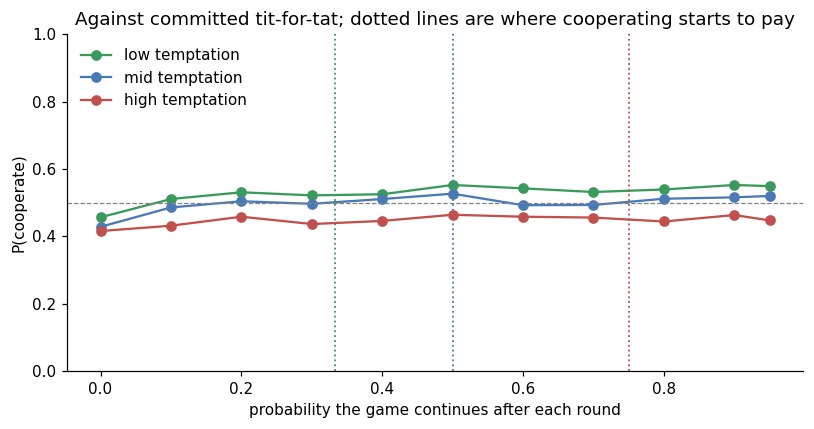

In [9]:
sweep = d[d.block == 'delta_sweep']
thresholds = save('delta_thresholds', M.threshold_table(sweep))
display(thresholds)
curve = sweep.pivot_table(index='delta', columns=['opponent', 'payoff_set'], values='p_coop_choice')
flat = curve.copy(); flat.columns = [f'{a}|{b}' for a, b in flat.columns]
save('delta_curves', flat.reset_index())

fig, ax = plt.subplots(figsize=(7.5, 4))
colours = {'low_temptation': '#3a9a5b', 'mid_temptation': '#4a7ab5', 'high_temptation': '#c0504d'}
for payoff_set, colour in colours.items():
    ax.plot(curve.index, curve[('tit_for_tat', payoff_set)], marker='o', color=colour,
            label=f'{payoff_set.replace("_", " ")}')
    threshold = thresholds.query('payoff_set == @payoff_set').theoretical_threshold.iloc[0]
    ax.axvline(threshold, color=colour, ls=':', lw=1.2)
ax.axhline(0.5, color='grey', lw=0.8, ls='--')
ax.set_ylim(0, 1)
ax.set_xlabel('probability the game continues after each round')
ax.set_ylabel('P(cooperate)')
ax.set_title('Against committed tit-for-tat; dotted lines are where cooperating starts to pay')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Does a known finite horizon read differently from an open-ended one?

Against an unknown opponent, backward induction says defect at every finite horizon.
Against a *committed* tit-for-tat machine over a known finite run, the optimum is to
cooperate until the final round (confirmed by exact dynamic programming), so the
first-round answer is cooperate.

In [10]:
horizon = d[d.block == 'horizon'].copy()
horizon['setting'] = horizon.horizon + np.where(
    horizon.rounds.notna(), ' ' + horizon.rounds.fillna(0).astype(int).astype(str),
    np.where(horizon.delta.notna(), ' d=' + horizon.delta.astype(str), ''))
horizon_table = (horizon.groupby(['opponent', 'setting'])
                 .agg(n=('p_coop_choice', 'size'), p_coop=('p_coop_choice', 'mean'),
                      best_response=('best_response', 'first')).reset_index())
display(save('horizon_effect', horizon_table))

,opponent,setting,n,p_coop,best_response
0,tit_for_tat,finite 10,16,0.395625,cooperate
1,tit_for_tat,finite 100,16,0.405000,cooperate
2,tit_for_tat,finite 2,16,0.311250,cooperate
3,tit_for_tat,finite 5,16,0.369375,cooperate
4,tit_for_tat,indefinite d=0.5,16,0.525625,None
5,tit_for_tat,indefinite d=0.9,16,0.520000,cooperate
6,tit_for_tat,one_shot,16,0.262500,defect
7,unknown,finite 10,16,0.534375,defect
8,unknown,finite 100,16,0.565625,defect
9,unknown,finite 2,16,0.486875,defect


## 6. Does it best-respond to an opponent that has already committed?

In [11]:
by_opponent = M.accuracy_table(d[d.block.isin(['opponent', 'horizon'])], ['opponent', 'horizon'])
display(save('accuracy_by_opponent', by_opponent))

,opponent,horizon,n,best_response,accuracy,p_best_action,ci_low,ci_high
0,always_cooperate,indefinite,16,defect,1.00000,0.963125,0.954375,0.971875
1,always_cooperate,one_shot,16,defect,1.00000,0.971250,0.961250,0.980000
2,always_defect,indefinite,16,defect,0.00000,0.293125,0.250625,0.336250
3,always_defect,one_shot,16,defect,1.00000,0.753125,0.711875,0.794375
4,grim_trigger,indefinite,16,cooperate,0.00000,0.360000,0.317500,0.399375
5,grim_trigger,one_shot,16,defect,1.00000,0.891875,0.877500,0.906250
6,random_half,indefinite,16,defect,0.50000,0.555625,0.480625,0.630625
7,random_half,one_shot,16,defect,1.00000,0.737500,0.702500,0.771875
8,tit_for_tat,finite,64,cooperate,0.00000,0.370312,0.354531,0.386250
9,tit_for_tat,indefinite,32,cooperate,0.75000,0.520000,0.509688,0.529375


## 7. Invariance: rewording and rescaling must not move the answer

Both manipulations provably leave a payoff maximiser's choice unchanged, so the
reference value for every spread below is exactly zero.

,family,levels,min,max,range,sd,argmin,argmax
0,harmony,6,0.249375,0.911875,0.66250,0.228713,cooperate_defect,abstract
1,prisoners_dilemma,6,0.022500,0.238750,0.21625,0.072624,commons,abstract


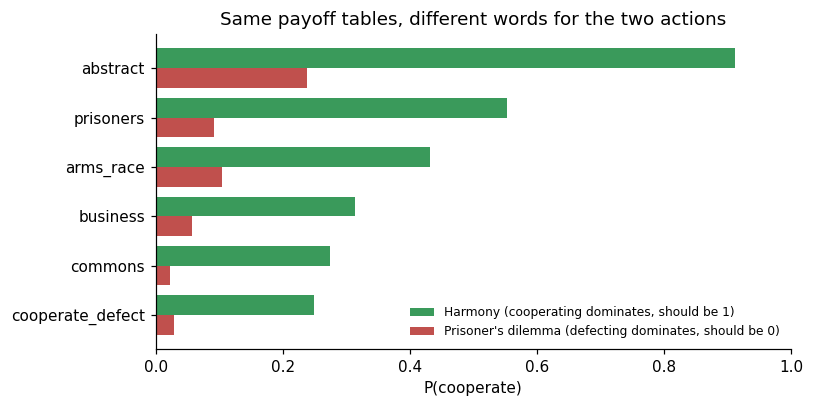

In [12]:
display(save('framing_invariance', M.invariance_table(d[d.block == 'framing'], 'frame', ['family'])))
frames = d[d.block == 'framing'].groupby(['family', 'frame'])['p_coop_choice'].mean().unstack()
save('framing_detail', frames.reset_index())

order_frames = ['abstract', 'prisoners', 'arms_race', 'business', 'commons', 'cooperate_defect']
fig, ax = plt.subplots(figsize=(7.5, 3.8))
y = np.arange(len(order_frames))
ax.barh(y - 0.2, frames.loc['harmony', order_frames], height=0.4, color='#3a9a5b',
        label='Harmony (cooperating dominates, should be 1)')
ax.barh(y + 0.2, frames.loc['prisoners_dilemma', order_frames], height=0.4, color='#c0504d',
        label='Prisoner\'s dilemma (defecting dominates, should be 0)')
ax.set_yticks(y, order_frames)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('P(cooperate)')
ax.set_title('Same payoff tables, different words for the two actions')
ax.legend(frameon=False, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
display(save('affine_invariance', M.invariance_table(d[d.block == 'affine'], 'transform', ['base_family'])))
affine = d[d.block == 'affine'].groupby(['base_family', 'transform'])['p_coop_choice'].mean().unstack()
display(save('affine_detail', affine.reset_index()))

,base_family,levels,min,max,range,sd,argmin,argmax
0,harmony,6,0.901875,0.988125,0.086250,0.035319,identity,shift_up
1,prisoners_dilemma,6,0.200625,0.480000,0.279375,0.102131,shift_up,tenth


transform,base_family,identity,loss_framed,scale_and_shift,shift_up,tenth,times_ten
0,harmony,0.901875,0.903125,0.971875,0.988125,0.98125,0.958125
1,prisoners_dilemma,0.235625,0.371250,0.223750,0.200625,0.48000,0.222500


## 8. Presentation bias, reliability and internal coherence

Each request asks for the decision three ways at once (a choice, a yes/no, and a
five-point lean), so disagreement between them is internal to a single response.

,cells,mean_signed_gap,ci_low,ci_high,mean_absolute_gap,abs_ci_low,abs_ci_high
0,162,-0.040965,-0.050594,-0.031255,0.055388,0.047809,0.063267


,readout,cells,mean_within_cell_sd,ci_low,ci_high
0,choice,324,0.025885,0.024492,0.027311
1,noul,324,0.016326,0.015437,0.017280
2,score,324,0.019076,0.017941,0.020296


,pair,n,pearson_r,mean_abs_gap,same_side_of_half
0,choice vs noul,2184,0.887403,0.110723,0.813645
1,choice vs score,2184,0.869784,0.110492,0.858059
2,noul vs score,2184,0.841359,0.054016,0.769689


,block,n,choice_vs_noul_r,mean_abs_gap,same_side
0,affine,192.0,0.977185,0.173177,0.963542
1,delta_sweep,792.0,0.587489,0.059533,0.709596
2,family,160.0,0.965352,0.151313,0.831250
3,framing,192.0,0.951003,0.125521,0.921875
4,greed_fear,432.0,0.692257,0.146481,1.000000
5,horizon,224.0,0.557036,0.093437,0.642857
6,opponent,192.0,0.630864,0.150521,0.750000


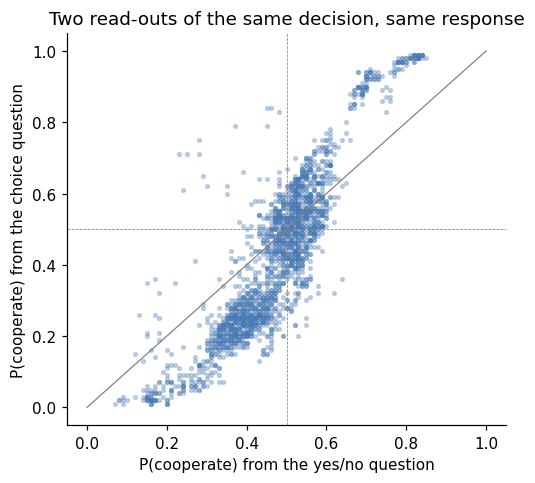

In [14]:
CELL = ['block', 'family', 'frame', 'instruction', 'horizon', 'rounds', 'delta',
        'opponent', 'greed', 'fear', 'transform', 'payoff_set']
bias = save('position_bias', M.position_bias(d, CELL))
reliability = save('reliability', M.reliability(d, CELL + ['coop_first']))
coherence = save('coherence', M.coherence_table(d))
display(bias, reliability, coherence)

by_block = (d.groupby('block')
            .apply(lambda g: pd.Series({
                'n': len(g),
                'choice_vs_noul_r': g.p_coop_choice.corr(g.p_coop_noul),
                'mean_abs_gap': (g.p_coop_choice - g.p_coop_noul).abs().mean(),
                'same_side': ((g.p_coop_choice > 0.5) == (g.p_coop_noul > 0.5)).mean()}),
                include_groups=False)
            .reset_index())
display(save('coherence_by_block', by_block))

fig, ax = plt.subplots(figsize=(4.8, 4.5))
ax.scatter(d.p_coop_noul, d.p_coop_choice, s=6, alpha=0.3, color='#4a7ab5')
ax.plot([0, 1], [0, 1], color='grey', lw=0.8)
ax.axhline(0.5, color='grey', lw=0.5, ls='--'); ax.axvline(0.5, color='grey', lw=0.5, ls='--')
ax.set_xlabel('P(cooperate) from the yes/no question')
ax.set_ylabel('P(cooperate) from the choice question')
ax.set_title('Two read-outs of the same decision, same response')
plt.tight_layout()
plt.show()

## 9. Operational cost and speed

Billed per distinct request, not per trial row.

In [15]:
distinct = d.drop_duplicates('record_key')
display(save('operational', pd.DataFrame([{
    'distinct_requests': len(distinct),
    'total_cost_usd': float(distinct.cost.sum()),
    'cost_per_request_usd': float(distinct.cost.mean()),
    'median_latency_s': float(distinct.latency_seconds.median()),
    'p95_latency_s': float(distinct.latency_seconds.quantile(0.95)),
    'mean_choice_confidence': float(d.choice_confidence.mean()),
}])))

,distinct_requests,total_cost_usd,cost_per_request_usd,median_latency_s,p95_latency_s,mean_choice_confidence
0,2024,0.059776,0.00003,0.2583,0.3315,0.374267


## Scorecard

One row per claim, each against an explicit reference.

In [16]:
def acc(subset):
    scored = subset[subset.best_response.notna()]
    if not len(scored):
        return float('nan')
    return float((scored.picked_cooperate == (scored.best_response == 'cooperate')).mean())

static = d[d.block.isin(['family', 'greed_fear'])]
committed = d[(d.block == 'opponent') & (d.opponent != 'unknown')]
one_shot_pd = d[(d.block == 'family') & (d.family == 'prisoners_dilemma')
                & (d.instruction == 'self_interest')].p_coop_choice.mean()
zero_delta = sweep[(sweep.delta == 0) & (sweep.payoff_set == 'mid_temptation')
                   & (sweep.opponent == 'unknown')].p_coop_choice.mean()
tft = thresholds[thresholds.opponent == 'tit_for_tat']

scorecard = pd.DataFrame([
    ('Ordinal game-family ranking', 'Spearman rho vs theory', rho, 1.0, 'pass'),
    ('Dominance in abstract one-shot games', 'accuracy', acc(static), 1.0, 'pass'),
    ('Best response to a committed opponent', 'accuracy', acc(committed), 1.0, 'mixed'),
    ('  of which one-shot', 'accuracy', acc(committed[committed.horizon == 'one_shot']), 1.0, 'pass'),
    ('  of which indefinitely repeated', 'accuracy',
     acc(committed[committed.horizon == 'indefinite']), 1.0, 'fail'),
    ('Known-finite horizon', 'accuracy', acc(d[d.block == 'horizon']), 1.0, 'fail'),
    ('Overall, all scoreable trials', 'accuracy', acc(d), 1.0, 'mixed'),
    ('Incentive gradient', 'd P(coop) / d log greed', float(beta[0]), None, 'weak'),
    ('Folk-theorem threshold', 'mean |observed - predicted| delta',
     float((tft.observed_crossing - tft.theoretical_threshold).abs().mean()), 0.0, 'fail'),
    ('Repetition framing at zero continuation', 'P(coop) minus one-shot',
     float(zero_delta - one_shot_pd), 0.0, 'fail'),
    ('Framing invariance', 'widest range across 6 wordings',
     float(M.invariance_table(d[d.block == 'framing'], 'frame', ['family'])['range'].max()), 0.0, 'fail'),
    ('Affine invariance', 'widest range across 6 rescalings',
     float(M.invariance_table(d[d.block == 'affine'], 'transform', ['base_family'])['range'].max()), 0.0, 'fail'),
    ('Presentation invariance', 'mean signed gap', float(bias.mean_signed_gap.iloc[0]), 0.0, 'fail'),
    ('Test-retest reliability', 'within-cell sd of P(coop)',
     float(reliability.mean_within_cell_sd.iloc[0]), 0.0, 'pass'),
    ('Internal coherence, choice vs noul', 'share on the same side of 0.5',
     float(coherence.same_side_of_half.iloc[0]), 1.0, 'fail'),
    ('Cost per decision', 'USD', float(distinct.cost.mean()), None, 'pass'),
    ('Median latency', 'seconds', float(distinct.latency_seconds.median()), None, 'pass'),
], columns=['metric', 'units', 'value', 'reference', 'verdict'])
display(save('scorecard', scorecard).round(4))
print(f'metric tables written to {OUT}')

,metric,units,value,reference,verdict
0,Ordinal game-family ranking,Spearman rho vs theory,1.0000,1.0,pass
1,Dominance in abstract one-shot games,accuracy,1.0000,1.0,pass
2,Best response to a committed opponent,accuracy,0.7250,1.0,mixed
3,of which one-shot,accuracy,1.0000,1.0,pass
4,of which indefinitely repeated,accuracy,0.4500,1.0,fail
5,Known-finite horizon,accuracy,0.3523,1.0,fail
6,"Overall, all scoreable trials",accuracy,0.7828,1.0,mixed
7,Incentive gradient,d P(coop) / d log greed,-0.0166,NaN,weak
8,Folk-theorem threshold,mean |observed - predicted| delta,0.6357,0.0,fail
9,Repetition framing at zero continuation,P(coop) minus one-shot,0.2146,0.0,fail


metric tables written to jev_bench_runs/game-theory-2898947bb72f3502/metrics


## Reading this

JEV reads static incentives almost perfectly: it ranks the five families exactly as
theory does and takes the dominant action in every abstract one-shot game. It is much
weaker on anything strategic (repeated games, committed opponents, known deadlines),
and it is not invariant to changes that cannot matter: renaming the two actions,
rescaling the payoffs, or which letter the cooperative action is given.

**Limits.** Every cell is a single decision about a stated payoff table, so this tests
reading incentives, not playing a game: JEV never sees a history or updates on an
opponent. The 78% overall accuracy averages over a deliberately adversarial design that
over-samples cases where theory makes a sharp prediction, so it is a profile rather
than a grade.